In [1]:
from pycromanager import Core
# from pycromanager import Magellan
from pycromanager import Dataset
import thorlabs_apt as apt
from thorlabs_apt import _APTAPI
import napari
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image
from scipy.signal import convolve2d
import pandas as pd

import CL3_functions

# core = Core()
# print(core)

## Set up experiment object

In [2]:
exp = CL3_functions.Exp()
# dir(exp.core)

# Image-guided MSI acquisition

## Basic image acq. (single snap)

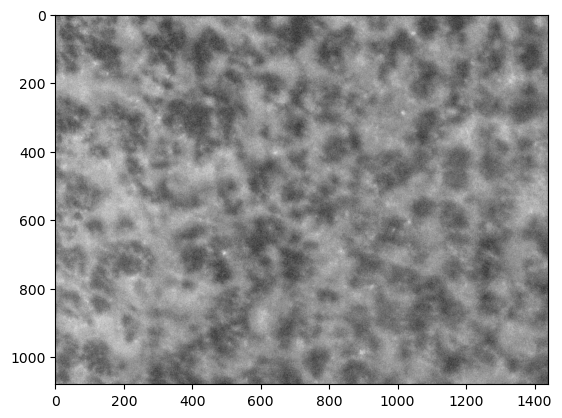

In [7]:
# exp.core.set_property("TSICam", "Exposure", 10)
# exp.core.set_property("TSICam", "Gain", 25)
exp.core.snap_image()
tagged_image = exp.core.get_image()
pixels = np.reshape(tagged_image,
                        newshape=[exp.core.get_image_height(), exp.core.get_image_width(),4])
# plot it
plt.imshow(pixels[:,:,1], cmap='gray')
plt.show()

## Tile acq.

In [8]:
[images, locs, grid_X, grid_Y] = exp.acquire_tile(acq_area_x = 5, acq_area_y = 5, x_flip = 1, y_flip = -1, pixel = 0.258)

0/252
1/252
2/252
3/252
4/252
5/252
6/252
7/252
8/252
9/252
10/252
11/252
12/252
13/252
14/252
15/252
16/252
17/252
18/252
19/252
20/252
21/252
22/252
23/252
24/252
25/252
26/252
27/252
28/252
29/252
30/252
31/252
32/252
33/252
34/252
35/252
36/252
37/252
38/252
39/252
40/252
41/252
42/252
43/252
44/252
45/252
46/252
47/252
48/252
49/252
50/252
51/252
52/252
53/252
54/252
55/252
56/252
57/252
58/252
59/252
60/252
61/252
62/252
63/252
64/252
65/252
66/252
67/252
68/252
69/252
70/252
71/252
72/252
73/252
74/252
75/252
76/252
77/252
78/252
79/252
80/252
81/252
82/252
83/252
84/252
85/252
86/252
87/252
88/252
89/252
90/252
91/252
92/252
93/252
94/252
95/252
96/252
97/252
98/252
99/252
100/252
101/252
102/252
103/252
104/252
105/252
106/252
107/252
108/252
109/252
110/252
111/252
112/252
113/252
114/252
115/252
116/252
117/252
118/252
119/252
120/252
121/252
122/252
123/252
124/252
125/252
126/252
127/252
128/252
129/252
130/252
131/252
132/252
133/252
134/252
135/252
136/252
137/252
138/25

## Stiching algo.

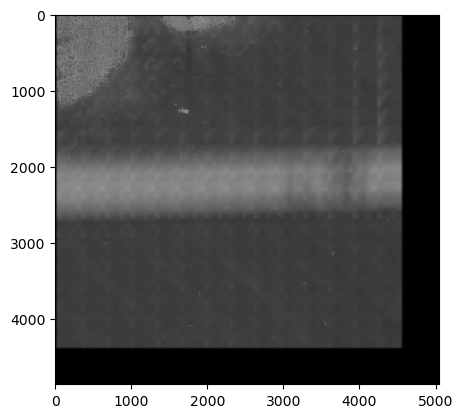

In [9]:
ImR = exp.stitch_tiles(images, grid_dims = [np.max(grid_X)+1,np.max(grid_Y)+1], save = True)

## ROI selection with Napari

In [9]:
# with Image.open('whole_tissue.png') as img:
#     img.load()
# ImR = np.array(img)
v = napari.Viewer()
v.add_image(ImR)
napari.run()

# exp_data = Dataset('C:/Users/olive/Dropbox/FIM/Data/test_021224_8')
# # exp_data
# exp_dask = exp_data.as_array(stitched=True)
# exp_dask = exp_data.as_array()
# v.layers['exp_dask'].contrast_limits = (0, 400)

C:\Users\olive\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\olive\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\olive\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


### Calculate start position & XY parameters for exp file

In [10]:
[start_pos,image_width,image_height] = exp.calculate_ROI('brain_test2.csv' ,x_flip = 1, y_flip = -1, grid_X = grid_X, grid_Y = grid_Y, locs = locs)
# path = 'optical ROIs/'
# filename = 'brain_test2.csv'
# ROI = pd.read_csv(path+filename)

the ROI starting position will be [114.33 134.04]& the size will be 
0.88 mm by
1.08mm


### Return to starting position & generate exp file to start run

In [12]:
exp.a1.position = start_pos[0]
exp.a2.position = start_pos[1]

x_pixel = 25
y_pixel = 25
exp.prepare('brain_test2',x_pixel,y_pixel, image_width, image_height, x_pixel*10)


pixel size (25,25)um^2,
image size ~(0.88,1.08)mm^2
velocity 250um/s
This means a time per line of ~3.52s (plus flyback), and 43 or 44 lines.

New .exp file created for use in MassLynx (testing still required!):
C:/Users/olive/Dropbox/FIM/Scripts/2025_10_20_brain_test2.exp
this run ROI will exceed the stage limit!!! pleace check


## Start Run!

In [ ]:
exp.do_full_raster()

# Wellplate Reading

In [15]:
exp.wellplate_read(x_flip = 1, y_flip = -1)

Scanning well 1 ...
Next well.
Scanning well 2 ...
Next well.
Scanning well 3 ...
Next well.
Scanning well 4 ...
Next well.
Scanning well 5 ...
Next well.
Scanning well 6 ...
Next well.
Scanning well 7 ...
Next well.
Scanning well 8 ...
Next well.
Scanning well 9 ...
Next well.
Scanning well 10 ...
Next well.
Scanning well 11 ...
Next well.
Scanning well 12 ...
Next well.
Scanning well 13 ...
Next well.
Scanning well 14 ...
Next well.
Scanning well 15 ...
Next well.
Scanning well 16 ...
Next well.
Scanning well 17 ...
Next well.
Scanning well 18 ...
Next well.
Scanning well 19 ...
Next well.
Scanning well 20 ...
Next well.
Scanning well 21 ...
Next well.
Scanning well 22 ...
Next well.
Scanning well 23 ...
Next well.
Scanning well 24 ...
Next well.
Scanning well 25 ...
Next well.
Scanning well 26 ...
Next well.
Scanning well 27 ...
Next well.
Scanning well 28 ...
Next well.
Scanning well 29 ...
Next well.
Scanning well 30 ...
Next well.
Scanning well 31 ...
Next well.
Scanning well 32 

KeyboardInterrupt: 

In [ ]:
# from pycromanager import XYTiledAcquisition

# with XYTiledAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test_06102025', tile_overlap=10) as acq:
#     # 10 pixel overlap between adjacent tiles

#     # Acquire a 2 x 1 grid
#     acq.acquire({'axes': {'row': 0, 'col': 0}})
#     acq.acquire({'axes': {'row': 1, 'col': 0}})

In [72]:
# from pycromanager import ExploreAcquisition

# acq = ExploreAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test2_021224', z_step_um=0, tile_overlap=50)
# acq.mark_finished()
# acq.await_completion()

In [73]:
# TLX = core.get_x_position()
# TLY = core.get_y_position()
# print([TLX,TLY])
# print(dir(core))

In [5]:
# from pycromanager import MagellanAcquisition

# # no need to use the normal "with" syntax because these acquisition are cleaned up automatically
# acq = MagellanAcquisition(magellan_acq_index=0)

# # Or do this to launch an explore acquisition
# acq = MagellanAcquisition(magellan_explore=True)

# # Optional: block here until the acquisition is finished
# acq.await_completion()

In [ ]:
# from pycromanager import XYTiledAcquisition

# with XYTiledAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test', tile_overlap=10) as acq:
#     # 10 pixel overlap between adjacent tiles

#     # Acquire a 2 x 1 grid
#     acq.acquire({'axes': {'row': 0, 'col': 0}})
#     acq.acquire({'axes': {'row': 1, 'col': 0}})